# **Caso 2 — Ciclo de vida ML end-to-end**
## **Predicción de fuga de clientes (Churn) · Naowee S.A.S**

**Dataset:** Telco Customer Churn (IBM) | **Clientes:** 7,043 | **Variables:** 21

Una empresa de telecomunicaciones necesita identificar de forma temprana a los
clientes con alto riesgo de fuga, para activar campañas de retención focalizadas.
Este notebook cubre el ciclo de vida completo: desde el entendimiento de los datos
hasta un modelo de clasificación listo para producción.

---
## Tabla de contenido
- [01 · Configuración del entorno](#01)
- [02 · Perfilado de datos](#02)
- [03 · Limpieza y transformación](#03)
- [04 · Análisis exploratorio](#04)
- [05 · Definición del problema e ingeniería de características](#05)
- [06 · Modelado](#06)
- [07 · Interpretabilidad](#07)

## **01 · Configuración del entorno**

In [1]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
import os

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)
SEED = 42
np.random.seed(SEED)

c:\Users\catao\miniconda3\envs\hotelbook\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import kagglehub
import os

path = kagglehub.dataset_download("blastchar/telco-customer-churn")
print(f"Dataset descargado en: {path}")

for f in os.listdir(path):
    print(" ·", f)

Dataset descargado en: C:\Users\catao\.cache\kagglehub\datasets\blastchar\telco-customer-churn\versions\1
 · WA_Fn-UseC_-Telco-Customer-Churn.csv


In [3]:
path = kagglehub.dataset_download("blastchar/telco-customer-churn")
csv_path = os.path.join(path, "WA_Fn-UseC_-Telco-Customer-Churn.csv")
df_raw = pd.read_csv(csv_path)

print(f"Dimensiones: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas")
df_raw.head(3)

Dimensiones: 7,043 filas × 21 columnas


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


## **02. Perfilado de datos**

### **Diccionario de variables — Telco Customer Churn (IBM)**

| Variable | Tipo | Descripción |
|---|---|---|
| `customerID` | Categórica | Identificador único del cliente. No aporta información predictiva — se excluye del análisis. |
| `gender` | Categórica | Género del cliente: `Male`, `Female`. |
| `SeniorCitizen` | Binaria (int) | Indica si el cliente es adulto mayor: `1` = sí, `0` = no. Único campo numérico binario en el dataset. |
| `Partner` | Binaria | Indica si el cliente tiene pareja: `Yes`, `No`. |
| `Dependents` | Binaria | Indica si el cliente vive con dependientes (hijos u otros): `Yes`, `No`. |
| `tenure` | Entera | Número de meses que el cliente lleva con la compañía. Rango: 0–72. |
| `PhoneService` | Binaria | Indica si el cliente tiene servicio de telefonía: `Yes`, `No`. |
| `MultipleLines` | Categórica | Indica si el cliente tiene múltiples líneas telefónicas: `Yes`, `No`, `No phone service`. |
| `InternetService` | Categórica | Tipo de servicio de internet contratado: `DSL`, `Fiber optic`, `No`. |
| `OnlineSecurity` | Categórica | Indica si el cliente tiene servicio de seguridad online: `Yes`, `No`, `No internet service`. |
| `OnlineBackup` | Categórica | Indica si el cliente tiene servicio de respaldo online: `Yes`, `No`, `No internet service`. |
| `DeviceProtection` | Categórica | Indica si el cliente tiene protección de dispositivos: `Yes`, `No`, `No internet service`. |
| `TechSupport` | Categórica | Indica si el cliente tiene soporte técnico con tiempos de espera reducidos: `Yes`, `No`, `No internet service`. |
| `StreamingTV` | Categórica | Indica si el cliente usa el servicio de internet para streaming de TV: `Yes`, `No`, `No internet service`. |
| `StreamingMovies` | Categórica | Indica si el cliente usa el servicio de internet para streaming de películas: `Yes`, `No`, `No internet service`. |
| `Contract` | Categórica | Tipo de contrato actual del cliente: `Month-to-month`, `One year`, `Two year`. |
| `PaperlessBilling` | Binaria | Indica si el cliente eligió facturación sin papel: `Yes`, `No`. |
| `PaymentMethod` | Categórica | Método de pago del cliente: `Electronic check`, `Mailed check`, `Bank transfer (automatic)`, `Credit card (automatic)`. |
| `MonthlyCharges` | Numérica | Cargo mensual total actual del cliente en dólares. |
| `TotalCharges` | Numérica | Cargo total acumulado del cliente en dólares |
| `Churn` | Binaria (target) | Indica si el cliente abandonó la compañía en el último mes: `Yes`, `No`. Variable objetivo del modelo de clasificación. |

## **02. Perfilado de datos**

In [4]:
df = df_raw.copy()

print("=" * 55)
print(f"  Filas     : {df.shape[0]:>10,}")
print(f"  Columnas  : {df.shape[1]:>10}")
print(f"  Duplicados: {df.duplicated().sum():>10,}")
print("=" * 55)

df.dtypes.to_frame("tipo").assign(
    nulos=df.isnull().sum(),
    pct_nulos=(df.isnull().mean() * 100).round(2),
    n_unicos=df.nunique(),
).sort_values("pct_nulos", ascending=False)

  Filas     :      7,043
  Columnas  :         21
  Duplicados:          0


,tipo,nulos,pct_nulos,n_unicos
customerID,str,0,0.00,7043
gender,str,0,0.00,2
SeniorCitizen,int64,0,0.00,2
Partner,str,0,0.00,2
Dependents,str,0,0.00,2
tenure,int64,0,0.00,73
PhoneService,str,0,0.00,2
MultipleLines,str,0,0.00,3
InternetService,str,0,0.00,3
OnlineSecurity,str,0,0.00,3


In [5]:
# TotalCharges llega como string — identificamos qué impide la conversión
df["TotalCharges_num"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print(f"Valores no convertibles en TotalCharges: {df['TotalCharges_num'].isnull().sum()}")
print(f"\nRegistros afectados:")
df[df["TotalCharges_num"].isnull()][["customerID","tenure","MonthlyCharges","TotalCharges","Churn"]]

Valores no convertibles en TotalCharges: 11

Registros afectados:


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


### Hallazgos del perfilado

- **Sin duplicados** — los 7,043 registros son únicos.
- **Sin nulos reales** — pandas no reporta nulos, pero `TotalCharges` llega
  como `str` y contiene 11 valores vacíos que no se detectan como nulos hasta
  intentar la conversión numérica.
- **`TotalCharges` como string** — los 11 valores no convertibles corresponden
  exactamente a clientes con `tenure = 0`. Son clientes nuevos que aún no han
  acumulado cargos. No es un error de registro — es la realidad del negocio.
- **Categorías redundantes** — variables como `OnlineSecurity`, `OnlineBackup`
  y otras 4 columnas de servicios contienen la categoría `No internet service`,
  que es redundante con `InternetService = No`. Se trata en la sección 03.

## **03 · Limpieza y transformación** <a id="03"></a>**

Cada decisión se documenta con su justificación. No se modifica `df_raw` —
todas las operaciones se aplican sobre `df`.

In [6]:
# ── TotalCharges ──────────────────────────────────────────────────────────
# Los 11 valores vacíos tienen tenure=0 — clientes sin cargos acumulados aún
# No es imputación estadística: 0 es el valor real del negocio
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(0)
df = df.drop(columns=["TotalCharges_num"])

print(f"Nulos en TotalCharges: {df['TotalCharges'].isnull().sum()}")

Nulos en TotalCharges: 0


In [7]:
# ── Categorías redundantes ────────────────────────────────────────────────
# "No internet service" y "No phone service" no agregan información nueva:
# InternetService = No y PhoneService = No ya capturan esa condición.
# Se colapsan a "No" para simplificar sin perder información.
cols_internet = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
                 "TechSupport", "StreamingTV", "StreamingMovies"]

df[cols_internet] = df[cols_internet].replace("No internet service", "No")
df["MultipleLines"] = df["MultipleLines"].replace("No phone service", "No")

# ── Churn a binaria ───────────────────────────────────────────────────────
df["Churn"] = (df["Churn"] == "Yes").astype(int)

# ── customerID — no aporta información predictiva ─────────────────────────
df = df.drop(columns=["customerID"])

print(f"Shape final : {df.shape}")
print(f"Nulos restantes: {df.isnull().sum().sum()}")

Shape final : (7043, 20)
Nulos restantes: 0


### Decisiones de limpieza

| Variable | Problema | Decisión | Justificación |
|---|---|---|---|
| `TotalCharges` | String con 11 vacíos | Convertir a float, vacíos → `0` | Los 11 casos tienen `tenure = 0`; sin tiempo de permanencia no hay cargo acumulado |
| `OnlineSecurity` y otras 5 | Categoría `No internet service` | Reemplazar por `No` | Redundante con `InternetService = No`; un cliente sin internet no puede tener ninguno de estos servicios |
| `MultipleLines` | Categoría `No phone service` | Reemplazar por `No` | Redundante con `PhoneService = No` |
| `Churn` | String `Yes`/`No` | Convertir a binaria `1`/`0` | Requerido para modelado; `1` = cliente fugado |
| `customerID` | Identificador único | Eliminar | No aporta información predictiva; incluirlo causaría data leakage |

## **04. Análisis exploratorio**

### **Hallazgos del perfil del cliente que se va**

El análisis bivariado revela un perfil consistente y accionable del cliente con alto riesgo de churn. 

**Tipo de contrato**

La tasa de churn pasa de 43% en contratos mes a mes a apenas 3% en contratos de dos años. Esto se puede basar en que el contrato de largo plazo es un compromiso explícito. El cliente mes a mes no tiene fricción para irse, puede cancelar en cualquier momento sin penalización. La cadencia del
contrato refleja la intención del cliente de permanecer en un largo plazo, pero tambien impone restricciones que imponen permanencia.

**Tenure (la ventana crítica son los primeros 12 meses)**

El 56% de los clientes que se van lo hacen dentro de su primer año. A partir del mes 24 la probabilidad de churn cae sostenidamente. Esto sugiere que la
relación cliente-empresa tiene un periodo de prueba implícito, Si supera ese umbral del primer año, tiende a quedarse.

**Servicio de internet (Fiber optic como señal de riesgo)**

Los clientes con Fiber optic cancelan al 42%, más del doble que los de DSL (19%). Aunque suene contraintuitivo, puesto que se esperaria que el servicio premium debería generar más satisfacción, una hipótesis plausible es que estos clientes tienen mayores expectativas de calidad y son más sensibles a problemas de servicio, o que el precio del servicio de fibra genera mayor carga financiera.

**Cargos mensuales (los churners pagan más)**

La mediana de cargos mensuales de los churners es $79.6 vs $64.4 en los que se quedan. Combinado con el hallazgo de Fiber optic, esto indica que el
segmento de mayor gasto no está percibiendo el valor proporcional al precio que paga.

**Método de pago**

Los clientes que pagan con cheque electrónico tienen una tasa de churn del 45%, casi el triple que los métodos automáticos (débito bancario ~17%, tarjeta ~15%). Con los métodos automáticos el cliente no tiene que tomar una acción activa cada mes para pagar, lo que reduce la fricción de salida. El
cheque electrónico, al requerir acción activa mensual, puede ser también un indicador de clientes menos dispuestos a una permanencia de largo plazo.

**Facturación sin papel**

Los clientes con facturación sin papel cancelan al 34% vs 16% con facturación tradicional. Puede estar correlacionado con el método de pago electrónico y
con un perfil de cliente más digital y comparativo, alguien que revisa su factura activamente cada mes tiene más oportunidades de cuestionar si el
servicio vale lo que paga.

---

> **Perfil síntesis del cliente en riesgo:** cliente relativamente nuevo
> (menos de 12 meses), con contrato mes a mes, servicio de Fiber optic,
> cargos mensuales altos, que paga con cheque electrónico y tiene facturación
> sin papel. Este perfil concentra la mayor probabilidad de churn y es
> el objetivo principal de las campañas de retención.

In [8]:
# Tasa de churn por variable categórica clave
for col in ["Contract", "InternetService", "PaymentMethod", "PaperlessBilling"]:
    print(f"\n── {col} ──")
    print(df.groupby(col)["Churn"].mean().round(3).sort_values(ascending=False))


── Contract ──
Contract
Month-to-month   0.43
One year         0.11
Two year         0.03
Name: Churn, dtype: float64

── InternetService ──
InternetService
Fiber optic   0.42
DSL           0.19
No            0.07
Name: Churn, dtype: float64

── PaymentMethod ──
PaymentMethod
Electronic check            0.45
Mailed check                0.19
Bank transfer (automatic)   0.17
Credit card (automatic)     0.15
Name: Churn, dtype: float64

── PaperlessBilling ──
PaperlessBilling
Yes   0.34
No    0.16
Name: Churn, dtype: float64


In [9]:
print(df.groupby("Churn")[["tenure", "MonthlyCharges", "TotalCharges"]].describe().round(1))

       tenure                                          MonthlyCharges        \
        count  mean   std  min   25%   50%   75%   max          count  mean   
Churn                                                                         
0     5174.00 37.60 24.10 0.00 15.00 38.00 61.00 72.00        5174.00 61.30   
1     1869.00 18.00 19.50 1.00  2.00 10.00 29.00 72.00        1869.00 74.40   

                                           TotalCharges                        \
        std   min   25%   50%   75%    max        count    mean     std   min   
Churn                                                                           
0     31.10 18.20 25.10 64.40 88.40 118.80      5174.00 2549.90 2330.00  0.00   
1     24.70 18.80 56.20 79.60 94.20 118.40      1869.00 1531.80 1890.80 18.80   

                                      
         25%     50%     75%     max  
Churn                                 
0     572.90 1679.50 4262.80 8672.40  
1     134.50  703.60 2331.30 8684.80  


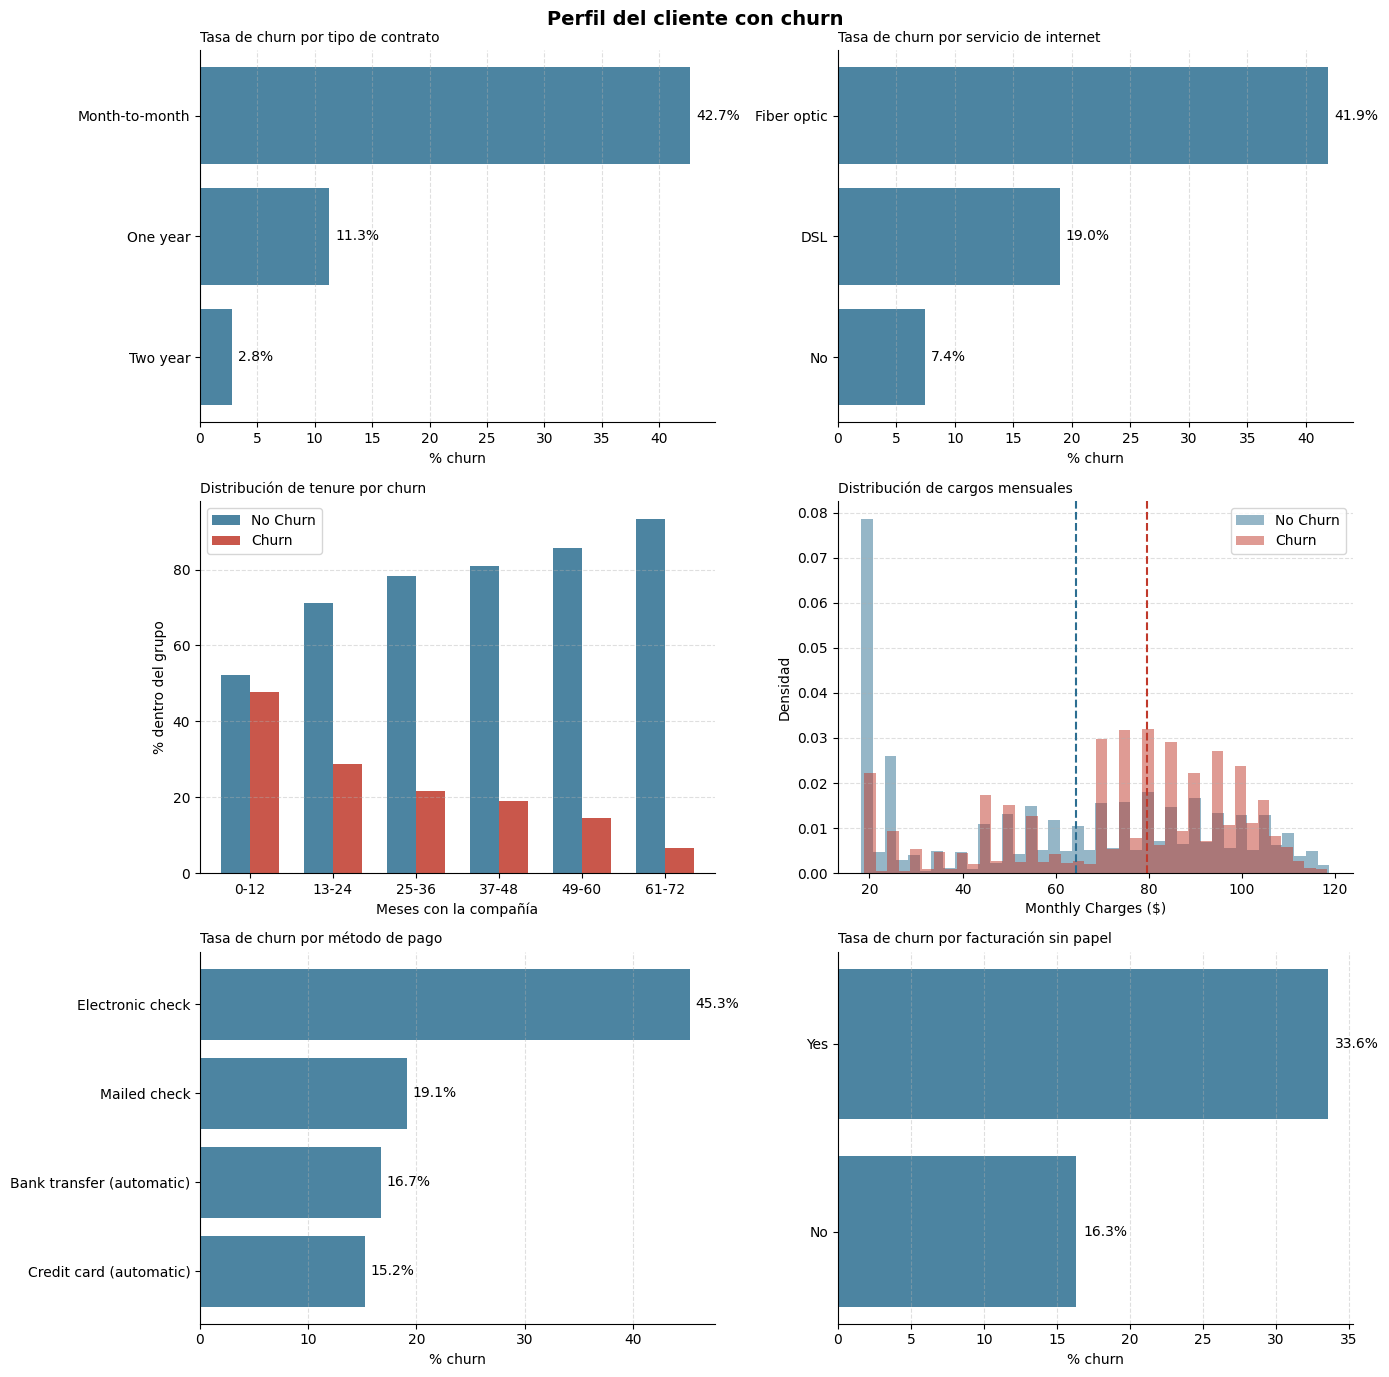

In [10]:
# ── 04 · EDA — Perfil del cliente que se va ──────────────────────────────

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
fig.suptitle("Perfil del cliente con churn", fontsize=14, fontweight="bold")

colores = {0: "#2C6E91", 1: "#C0392B"}
labels  = {0: "No Churn", 1: "Churn"}

# ── 1. Tasa de churn por tipo de contrato ──
contrato = df.groupby("Contract")["Churn"].mean().sort_values() * 100
axes[0,0].barh(contrato.index, contrato.values, color="#2C6E91", alpha=0.85)
for i, v in enumerate(contrato.values):
    axes[0,0].text(v + 0.5, i, f"{v:.1f}%", va="center", fontsize=10)
axes[0,0].set_title("Tasa de churn por tipo de contrato", fontsize=10, loc="left")
axes[0,0].set_xlabel("% churn")
axes[0,0].spines[["top","right"]].set_visible(False)
axes[0,0].grid(axis="x", linestyle="--", alpha=0.4)

# ── 2. Tasa de churn por servicio de internet ──
internet = df.groupby("InternetService")["Churn"].mean().sort_values() * 100
axes[0,1].barh(internet.index, internet.values, color="#2C6E91", alpha=0.85)
for i, v in enumerate(internet.values):
    axes[0,1].text(v + 0.5, i, f"{v:.1f}%", va="center", fontsize=10)
axes[0,1].set_title("Tasa de churn por servicio de internet", fontsize=10, loc="left")
axes[0,1].set_xlabel("% churn")
axes[0,1].spines[["top","right"]].set_visible(False)
axes[0,1].grid(axis="x", linestyle="--", alpha=0.4)

# ── 3. Distribución de tenure por churn ──
bins_tenure = [0, 12, 24, 36, 48, 60, 72]
labels_tenure = ["0-12", "13-24", "25-36", "37-48", "49-60", "61-72"]
df["tenure_rango"] = pd.cut(df["tenure"], bins=bins_tenure, labels=labels_tenure)

tenure_churn = (df.groupby(["tenure_rango", "Churn"], observed=True)
                .size().unstack().apply(lambda x: x/x.sum(), axis=1) * 100)

tenure_churn.plot(kind="bar", ax=axes[1,0], color=["#2C6E91","#C0392B"],
                  alpha=0.85, width=0.7)
axes[1,0].set_title("Distribución de tenure por churn", fontsize=10, loc="left")
axes[1,0].set_xlabel("Meses con la compañía")
axes[1,0].set_ylabel("% dentro del grupo")
axes[1,0].set_xticklabels(labels_tenure, rotation=0)
axes[1,0].legend(["No Churn", "Churn"])
axes[1,0].spines[["top","right"]].set_visible(False)
axes[1,0].grid(axis="y", linestyle="--", alpha=0.4)

# ── 4. Distribución de MonthlyCharges por churn ──
for churn_val, color in colores.items():
    subset = df[df["Churn"] == churn_val]["MonthlyCharges"]
    axes[1,1].hist(subset, bins=40, alpha=0.5, color=color,
                   label=labels[churn_val], density=True)
    axes[1,1].axvline(subset.median(), color=color, linewidth=1.5, linestyle="--")
axes[1,1].set_title("Distribución de cargos mensuales", fontsize=10, loc="left")
axes[1,1].set_xlabel("Monthly Charges ($)")
axes[1,1].set_ylabel("Densidad")
axes[1,1].legend()
axes[1,1].spines[["top","right"]].set_visible(False)
axes[1,1].grid(axis="y", linestyle="--", alpha=0.4)

# ── 5. Tasa de churn por método de pago ──
pago = df.groupby("PaymentMethod")["Churn"].mean().sort_values() * 100
axes[2,0].barh(pago.index, pago.values, color="#2C6E91", alpha=0.85)
for i, v in enumerate(pago.values):
    axes[2,0].text(v + 0.5, i, f"{v:.1f}%", va="center", fontsize=10)
axes[2,0].set_title("Tasa de churn por método de pago", fontsize=10, loc="left")
axes[2,0].set_xlabel("% churn")
axes[2,0].spines[["top","right"]].set_visible(False)
axes[2,0].grid(axis="x", linestyle="--", alpha=0.4)

# ── 6. Tasa de churn por facturación sin papel ──
billing = df.groupby("PaperlessBilling")["Churn"].mean().sort_values() * 100
axes[2,1].barh(billing.index, billing.values, color="#2C6E91", alpha=0.85)
for i, v in enumerate(billing.values):
    axes[2,1].text(v + 0.5, i, f"{v:.1f}%", va="center", fontsize=10)
axes[2,1].set_title("Tasa de churn por facturación sin papel", fontsize=10, loc="left")
axes[2,1].set_xlabel("% churn")
axes[2,1].spines[["top","right"]].set_visible(False)
axes[2,1].grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

## **05 · Ingeniería de características**

Las variables construidas parten directamente de los hallazgos del EDA.

| Feature | Fórmula | Hipótesis |
|---|---|---|
| `total_servicios` | Suma de servicios adicionales activos | Más servicios -> más valor percibido -> menor churn |
| `cargo_por_servicio` | `MonthlyCharges / (total_servicios + 1)` | Cliente que paga mucho por pocos servicios percibe menos valor |
| `riesgo_temprano` | `Contract == Month-to-month AND tenure ≤ 12` | La combinación más crítica identificada en el EDA — 51% de churn |
| `tenure_norm` | `tenure / 72` | Normaliza la antigüedad al rango [0,1] para estabilizar el modelo |



In [11]:
# ¿Cuántos servicios adicionales tiene el cliente?
servicios = ["OnlineSecurity","OnlineBackup","DeviceProtection",
             "TechSupport","StreamingTV","StreamingMovies"]
df["total_servicios"] = df[servicios].apply(lambda x: (x == "Yes").sum(), axis=1)
print(df.groupby("total_servicios")["Churn"].mean().round(3))

total_servicios
0   0.21
1   0.46
2   0.36
3   0.27
4   0.22
5   0.12
6   0.05
Name: Churn, dtype: float64


In [12]:
# ── 2. Cargo mensual por servicio ─────────────────────────────────────────
# Evitamos división por cero para clientes sin servicios adicionales
df["cargo_por_servicio"] = df["MonthlyCharges"] / (df["total_servicios"] + 1)

# ── 3. Interacción contrato × tenure early ────────────────────────────────
# Cliente mes a mes en periodo crítico (primeros 12 meses)
df["riesgo_temprano"] = (
    (df["Contract"] == "Month-to-month") & (df["tenure"] <= 12)
).astype(int)

# ── 4. Tenure normalizado ─────────────────────────────────────────────────
df["tenure_norm"] = df["tenure"] / 72

# Verificación
print(df.groupby("riesgo_temprano")["Churn"].mean().round(3))
print(f"\ncargo_por_servicio — media: {df['cargo_por_servicio'].mean():.2f}")

riesgo_temprano
0   0.17
1   0.51
Name: Churn, dtype: float64

cargo_por_servicio — media: 25.49


**Validación rápida de discriminación:**

- `total_servicios`: churn cae de 46% con 1 servicio a 5% con 6 — relación
  inversa clara a partir del segundo servicio.
- `riesgo_temprano`: 51% de churn vs 17% — la feature más discriminante
  del conjunto. Captura la intersección de dos señales fuertes del EDA.

## **Desbalance de clases**

El dataset presenta un desbalance moderado: 73.5% no churn vs 26.5% churn.

**¿Qué cuesta más en este problema?**

| Error | Consecuencia | Costo |
|---|---|---|
| Falso negativo | Predecir que el cliente se queda pero se va → sin acción de retención | **Alto** — perdemos el cliente |
| Falso positivo | Predecir que el cliente se va pero se queda → campaña de retención innecesaria | **Bajo** — costo operativo menor |

Dado que el objetivo es identificar a los clientes con intención de irse,
priorizamos **Recall** como métrica principal. Es preferible activar una
campaña de retención de más, que dejar ir a un cliente sin intervención.

**Estrategia:** `class_weight="balanced"` en todos los modelos. Este parámetro
penaliza proporcionalmente más los errores sobre la clase minoritaria (churn),
sin modificar el dataset ni generar datos sintéticos. Es la opción más
conservadora, interpretable y defendible para este tamaño de dataset.

## **Modelado**


In [13]:
print(df.dtypes)
print(f"\nColumnas categóricas: {df.select_dtypes('object').columns.tolist()}")

gender                     str
SeniorCitizen            int64
Partner                    str
Dependents                 str
tenure                   int64
PhoneService               str
MultipleLines              str
InternetService            str
OnlineSecurity             str
OnlineBackup               str
DeviceProtection           str
TechSupport                str
StreamingTV                str
StreamingMovies            str
Contract                   str
PaperlessBilling           str
PaymentMethod              str
MonthlyCharges         float64
TotalCharges           float64
Churn                    int64
tenure_rango          category
total_servicios          int64
cargo_por_servicio     float64
riesgo_temprano          int64
tenure_norm            float64
dtype: object

Columnas categóricas: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Dropeamos tenure_rango — redundante con tenure y tenure_norm
df_model = df.drop(columns=["tenure_rango"])

# Separamos features y target
X = df_model.drop(columns=["Churn"])
y = df_model["Churn"]

# Identificamos columnas por tipo de encoding
binarias = ["gender","Partner","Dependents","PhoneService","MultipleLines",
            "OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport",
            "StreamingTV","StreamingMovies","PaperlessBilling"]

multiclase = ["Contract","InternetService","PaymentMethod"]

numericas = ["SeniorCitizen","tenure","MonthlyCharges","TotalCharges",
             "total_servicios","cargo_por_servicio","riesgo_temprano","tenure_norm"]

# Split estratificado — conserva proporción de churn en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Churn en train: {y_train.mean():.3f}")
print(f"Churn en test : {y_test.mean():.3f}")

Train: (5634, 23) | Test: (1409, 23)
Churn en train: 0.265
Churn en test : 0.265


In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error

### **Modelo de regresión**

Se entrena un modelo de regresión lineal para predecir la antigüedad del cliente (`tenure`) usando las demás variables del dataset como predictores.

**Detección de variable contaminante**

Durante el análisis se identificó que `TotalCharges` tiene una correlación
de 0.83 con `tenure`. Esto no es coincidencia — matemáticamente:

`TotalCharges ≈ tenure × MonthlyCharges`

Incluirla en el modelo equivale a darle acceso implícito al target, lo que infla artificialmente el R². 

In [21]:
print(df_model[["tenure","TotalCharges"]].corr())

              tenure  TotalCharges
tenure          1.00          0.83
TotalCharges    0.83          1.00


**Se entrenaron dos versiones para cuantificar el impacto:**

In [24]:


# ── Modelo de regresión — target: tenure ─────────────────────────────────
X_reg = df_model.drop(columns=["Churn", "tenure", "tenure_norm"])
y_reg = df_model["tenure"]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=SEED
)

numericas_reg = ["SeniorCitizen","MonthlyCharges","TotalCharges",
                 "total_servicios","cargo_por_servicio","riesgo_temprano"]

preprocessor_reg = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numericas_reg),
    ("bin", OneHotEncoder(drop="if_binary", handle_unknown="ignore"), binarias),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), multiclase)
])

pipe_reg = Pipeline([
    ("prep", preprocessor_reg),
    ("reg", LinearRegression())
])

pipe_reg.fit(X_train_r, y_train_r)
y_pred_r = pipe_reg.predict(X_test_r)

rmse = root_mean_squared_error(y_test_r, y_pred_r)
mae  = mean_absolute_error(y_test_r, y_pred_r)
r2   = r2_score(y_test_r, y_pred_r)

print(f"RMSE : {rmse:.3f}")
print(f"MAE  : {mae:.3f}")
print(f"R²   : {r2:.3f}")

RMSE : 8.343
MAE  : 6.198
R²   : 0.889


In [25]:
# Sin TotalCharges
numericas_reg2 = ["SeniorCitizen","MonthlyCharges",
                  "total_servicios","cargo_por_servicio","riesgo_temprano"]

preprocessor_reg2 = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numericas_reg2),
    ("bin", OneHotEncoder(drop="if_binary", handle_unknown="ignore"), binarias),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), multiclase)
])

pipe_reg2 = Pipeline([
    ("prep", preprocessor_reg2),
    ("reg", LinearRegression())
])

X_reg2 = df_model.drop(columns=["Churn", "tenure", "tenure_norm", "TotalCharges"])

X_train_r2, X_test_r2, y_train_r2, y_test_r2 = train_test_split(
    X_reg2, y_reg, test_size=0.2, random_state=SEED
)

pipe_reg2.fit(X_train_r2, y_train_r2)
y_pred_r2 = pipe_reg2.predict(X_test_r2)

rmse2 = root_mean_squared_error(y_test_r2, y_pred_r2)
mae2  = mean_absolute_error(y_test_r2, y_pred_r2)
r2_2  = r2_score(y_test_r2, y_pred_r2)

print("Con TotalCharges:")
print(f"  RMSE: {rmse:.3f} | MAE: {mae:.3f} | R²: {r2:.3f}")
print("\nSin TotalCharges:")
print(f"  RMSE: {rmse2:.3f} | MAE: {mae2:.3f} | R²: {r2_2:.3f}")

Con TotalCharges:
  RMSE: 8.343 | MAE: 6.198 | R²: 0.889

Sin TotalCharges:
  RMSE: 12.682 | MAE: 9.732 | R²: 0.745


**El Modelo seleccionado es el sin TotalCharges** es el honesto. Un R² de 0.745 significa que el modelo explica el 74.5% de la varianza en tenure usando únicamente información disponible en el momento de la contratación — contrato, servicios, cargos mensuales y demografía.

El error promedio es de ~9.7 meses sobre un rango de 0 a 72 meses (~13.5% de error relativo). Es un modelo útil para estimar el ciclo de vida esperado
de un cliente nuevo, pero no es el producto principal de este caso — ese rol lo ocupa el modelo de clasificación de churn.

## **Modelo de clasificación**

El objetivo de esta sección es construir el producto de datos central del caso:
un modelo que identifique de forma temprana a los clientes con alto riesgo de fuga, para que el equipo de retención pueda intervenir antes de que se vayan.

El proceso sigue tres pasos:

1. **Preparación** — encoding de variables categóricas y split train/test
2. **Comparación** — tres modelos evaluados con validación cruzada estratificada
3. **Evaluación final** — el modelo seleccionado evaluado sobre el test set

Adicionalmente se entrena un **modelo de regresión** sobre `tenure` para
demostrar competencia en problemas de variable continua.

**Preparación de los datos**

Antes de entrenar cualquier modelo se toman dos decisiones importantes:

**Encoding de variables categóricas**

Los modelos de sklearn no aceptan strings — todas las variables categóricas
deben convertirse a números. Se usan dos estrategias según el tipo:

- **Variables binarias** (`Yes`/`No`): `OneHotEncoder(drop="if_binary")` —
  genera una sola columna donde 1 = Yes y 0 = No. No tiene sentido crear
  dos columnas cuando una es el complemento exacto de la otra.

- **Variables multiclase** (`Contract`, `InternetService`, `PaymentMethod`):
  `OneHotEncoder(drop="first")` — genera n-1 columnas para evitar
  multicolinealidad. La categoría eliminada queda como referencia implícita.

- **Variables numéricas**: `StandardScaler` — estandariza a media 0 y
  desviación estándar 1. Sin esto, variables con rangos muy distintos
  (`tenure`: 0-72 vs `MonthlyCharges`: 18-118) tendrían pesos artificialmente
  distintos solo por su escala.

**Todo el preprocesamiento va dentro del Pipeline** — esto garantiza que el
`StandardScaler` aprende la media y desviación únicamente del train, y aplica
esa misma transformación al test. Hacerlo fuera del pipeline sería data leakage.

**Split estratificado**

El `stratify=y` garantiza que la proporción de churn (26.5%) se conserve
igual en train y test. Sin esto, por azar podría quedar un set con muchos
más o menos churners, sesgando la evaluación.

**Comparación de modelos**

Se comparan tres modelos con validación cruzada estratificada de 5 folds
sobre el conjunto de entrenamiento. La validación cruzada divide el train
en 5 partes — entrena con 4 y evalúa con la quinta, rotando hasta evaluar
todas. Esto da una estimación más robusta del rendimiento real que un único
split, porque promedia el resultado sobre 5 evaluaciones distintas.

El **stratified** en la CV garantiza que cada fold conserve la proporción
de churn — crítico con clases desbalanceadas.

Los tres modelos candidatos y su estrategia de manejo del desbalance:

| Modelo | Manejo del desbalance |
|---|---|
| Logistic Regression | `class_weight="balanced"` |
| Random Forest | `class_weight="balanced"` |
| XGBoost | `scale_pos_weight` = ratio negativos/positivos |



In [26]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import classification_report, roc_auc_score
import warnings
warnings.filterwarnings("ignore")

# ── Preprocesador ─────────────────────────────────────────────────────────
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numericas),
    ("bin", OneHotEncoder(drop="if_binary", handle_unknown="ignore"), binarias),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), multiclase)
])

# ── Modelos ───────────────────────────────────────────────────────────────
modelos = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced", random_state=SEED, max_iter=1000),
    "Random Forest": RandomForestClassifier(
        class_weight="balanced", random_state=SEED, n_estimators=200),
    "XGBoost": XGBClassifier(
        scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]),
        random_state=SEED, eval_metric="logloss")
}

# ── CV estratificada ──────────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

resultados = {}
for nombre, modelo in modelos.items():
    pipe = Pipeline([("prep", preprocessor), ("clf", modelo)])
    scores = cross_validate(pipe, X_train, y_train, cv=cv,
                            scoring=["recall","precision","f1","roc_auc"],
                            return_train_score=False)
    resultados[nombre] = {
        "Recall"   : scores["test_recall"].mean(),
        "Precision": scores["test_precision"].mean(),
        "F1"       : scores["test_f1"].mean(),
        "ROC-AUC"  : scores["test_roc_auc"].mean(),
    }

# ── Tabla de resultados ───────────────────────────────────────────────────
df_resultados = pd.DataFrame(resultados).T.round(3)
df_resultados.style\
    .highlight_max(axis=0, color="#d4edda")\
    .format("{:.3f}")

,Recall,Precision,F1,ROC-AUC
Logistic Regression,0.797,0.519,0.628,0.846
Random Forest,0.644,0.575,0.607,0.830
XGBoost,0.646,0.549,0.594,0.818


**Métrica principal: Recall**

Como se definió en la sección de desbalance, priorizamos Recall — queremos
capturar la mayor cantidad posible de churners reales, aunque implique
algunas campañas de retención innecesarias.

| Modelo | Recall | Precision | F1 | ROC-AUC |
|---|---|---|---|---|
| **Logistic Regression** | **0.797** | 0.519 | 0.628 | **0.846** |
| Random Forest | 0.644 | 0.575 | 0.607 | 0.830 |
| XGBoost | 0.646 | 0.549 | 0.594 | 0.818 |

**Logistic Regression gana en Recall y ROC-AUC simultáneamente** — no hay
tradeoff que justifique elegir otro modelo. Es también el más interpretable
de los tres, lo que facilita explicar las predicciones al equipo de negocio.

**Evaluación sobre el test set**

Una vez seleccionado el modelo, se entrena sobre todo el train y se evalúa sobre el test set — datos que el modelo nunca vio durante el entrenamiento ni la selección.

Los resultados son consistentes con la CV (Recall 0.80 vs 0.797,
ROC-AUC 0.842 vs 0.846) — el modelo no está sobreajustado.


In [27]:
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)

# ── Entrenar modelo final sobre todo el train ─────────────────────────────
pipe_final = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(class_weight="balanced", 
                                random_state=SEED, max_iter=1000))
])
pipe_final.fit(X_train, y_train)

# ── Evaluación sobre test ─────────────────────────────────────────────────
y_pred  = pipe_final.predict(X_test)
y_proba = pipe_final.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")

              precision    recall  f1-score   support

    No Churn       0.91      0.72      0.80      1035
       Churn       0.50      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409

ROC-AUC: 0.842



La matriz de confusión desglosa los 1,409 registros del test set en cuatro categorías:

Para el negocio:

- **298 verdaderos positivos** — churners detectados. El equipo de retención puede intervenir antes de que se vayan. Son el valor central del modelo.

- **76 falsos negativos** — churners que el modelo no detectó. Se irán sin intervención. Este es el costo principal del modelo — 76 clientes perdidos de 374 reales (20%).

- **293 falsos positivos** — clientes que no iban a irse pero el modelo clasificó como churn. Se activa una campaña de retención innecesaria. El costo es operativo (recursos de campaña) pero significativamente menor que perder un cliente.

- **742 verdaderos negativos** — clientes estables correctamente ignorados.

### Curva ROC

La curva ROC muestra el tradeoff entre Recall y tasa de falsos positivos en todos los umbrales posibles. Un AUC de 0.842 significa que si tomamos un churner y un no-churner al azar, el modelo le asigna mayor probabilidad de churn al churner el 84.2% de las veces. La curva se aleja claramente de la diagonal de azar (AUC = 0.5), con una ganancia pronunciada en los primeros deciles — los churners reales se concentran en las probabilidades más altas predichas por el modelo.

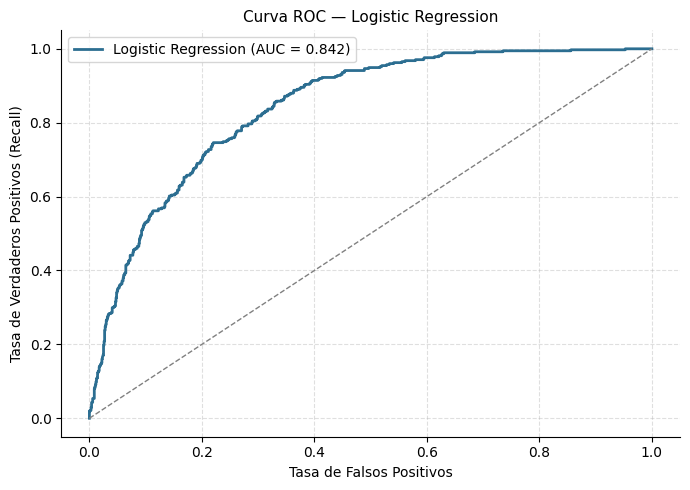

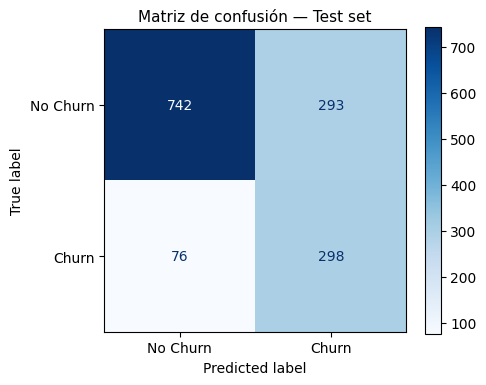

In [28]:
# ── Curva ROC ─────────────────────────────────────────────────────────────
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color="#2C6E91", linewidth=2,
         label=f"Logistic Regression (AUC = 0.842)")
plt.plot([0,1], [0,1], color="gray", linestyle="--", linewidth=1)
plt.xlabel("Tasa de Falsos Positivos", fontsize=10)
plt.ylabel("Tasa de Verdaderos Positivos (Recall)", fontsize=10)
plt.title("Curva ROC — Logistic Regression", fontsize=11)
plt.legend(fontsize=10)
plt.grid(linestyle="--", alpha=0.4)
plt.spines = plt.gca()
plt.gca().spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.show()

# ── Matriz de confusión ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["No Churn", "Churn"],
    cmap="Blues", ax=ax
)
ax.set_title("Matriz de confusión — Test set", fontsize=11)
plt.tight_layout()
plt.show()

**Interpretabilidad del modelo**

Los coeficientes de la Regresión Logística indican la dirección e intensidad con que cada variable empuja la probabilidad de churn, manteniendo las demás constantes. Al estar estandarizados, son comparables entre sí.

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Extraer nombres de features tras el preprocesamiento
feature_names = (
    numericas +
    pipe_final.named_steps["prep"]
    .named_transformers_["bin"]
    .get_feature_names_out(binarias).tolist() +
    pipe_final.named_steps["prep"]
    .named_transformers_["cat"]
    .get_feature_names_out(multiclase).tolist()
)

# Extraer coeficientes
coefs = pipe_final.named_steps["clf"].coef_[0]

# DataFrame ordenado por valor absoluto
df_coefs = (pd.DataFrame({"feature": feature_names, "coef": coefs})
            .assign(abs_coef=lambda x: x["coef"].abs())
            .sort_values("abs_coef", ascending=False)
            .head(15))

print(df_coefs[["feature","coef"]].to_string())

                           feature  coef
21               Contract_Two year -1.49
22     InternetService_Fiber optic  1.08
23              InternetService_No -1.00
20               Contract_One year -0.66
13              OnlineSecurity_Yes -0.43
25  PaymentMethod_Electronic check  0.41
16                 TechSupport_Yes -0.37
1                           tenure -0.35
7                      tenure_norm -0.35
19            PaperlessBilling_Yes  0.35
12               MultipleLines_Yes  0.34
2                   MonthlyCharges -0.33
11                PhoneService_Yes -0.31
18             StreamingMovies_Yes  0.29
6                  riesgo_temprano  0.29


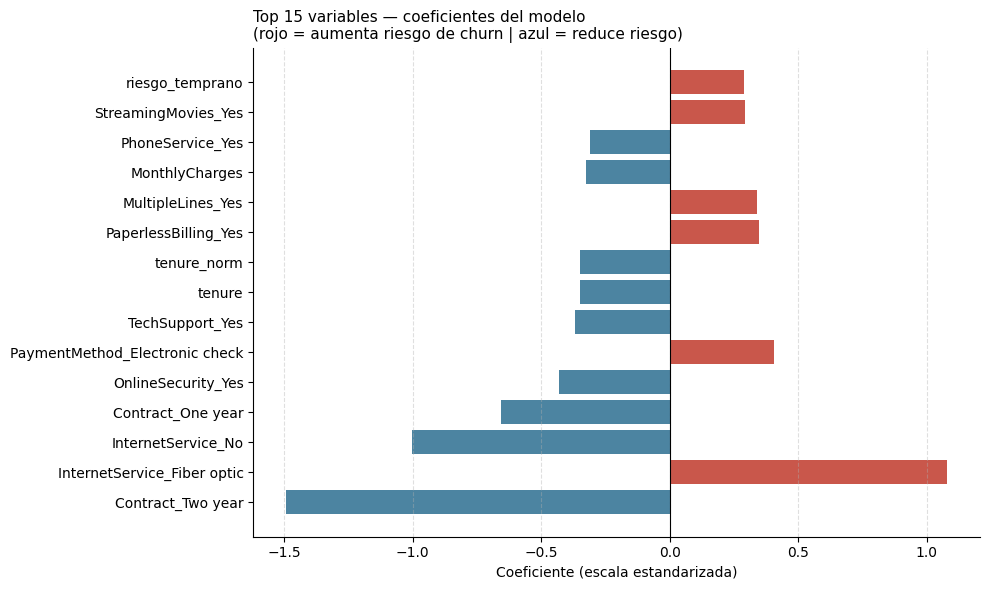

In [30]:
# ── Visualización de coeficientes ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

colores = ["#C0392B" if c > 0 else "#2C6E91" for c in df_coefs["coef"]]

ax.barh(df_coefs["feature"], df_coefs["coef"], color=colores, alpha=0.85)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Top 15 variables — coeficientes del modelo\n(rojo = aumenta riesgo de churn | azul = reduce riesgo)",
             fontsize=11, loc="left")
ax.set_xlabel("Coeficiente (escala estandarizada)", fontsize=10)
ax.spines[["top","right"]].set_visible(False)
ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


**Variables que aumentan el riesgo de churn (coef > 0)**

- **`InternetService_Fiber optic` (1.08)**.  El predictor positivo más fuerte.
  Los clientes de fibra óptica tienen mayor probabilidad de churn,
  consistente con lo visto en el EDA. Esto podría explicaese por las expectativas más altas de calidad de estos clientes, mayor sensibilidad al precio o problemas de servicio, no capturados en el dataset.

- **`PaymentMethod_Electronic check` (0.41)** :El segundo predictor positivo más fuerte. El pago manual activo cada mes puede ser un indicador de menor compromiso con la relación y mayor disposición a cancelar.

- **`PaperlessBilling_Yes` (0.35)**: Los clientes digitales que revisan su factura activamente tienen más oportunidades de cuestionar el valor del servicio.

- **`MultipleLines_Yes` (0.34)**: Tener múltiples líneas
  aumenta el riesgo. Puede estar correlacionado con cargos mensuales más altos sin servicios adicionales de valor agregado.

- **`riesgo_temprano` (0.29)**: El cliente mes a mes en primeros 12 meses es una señal clara de riesgo.

**Variables que reducen el riesgo de churn (coef < 0)**

- **`Contract_Two year` (-1.49)**: Es el protector más fuerte. Un contrato de dos años es el mayor ancla de retención disponible. La empresa debería incentivar activamente la migración a contratos largos.

- **`InternetService_No` (-1.00)**: Los clientes sin internet son los más estables. Son perfiles básicos con pocas expectativas y bajo costo de servicio.

- **`Contract_One year` (-0.66)** : Un año de compromiso reduce sustancialmente el riesgo vs mes a mes.

- **`OnlineSecurity_Yes` (-0.43)** : Los servicios de valor agregado generan dependencia y percepción de valor.

- **`TechSupport_Yes` (-0.37)** : El soporte técnico crea
  una relación de servicio activa que retiene al cliente.

- **`tenure` / `tenure_norm` (-0.35)** : A mayor antigüedad, menor riesgo. Confirma que superar la ventana crítica inicial estabiliza la relación.

### **Síntesis para el negocio**

El modelo identifica dos palancas principales de retención:

1. **Migrar clientes de contrato mes a mes a contratos anuales o bianuales**
   — es la acción con mayor impacto individual en reducir churn.
2. **Activar servicios de valor agregado** (OnlineSecurity, TechSupport)
   en clientes de Fiber optic con alto cargo mensual y sin servicios
   adicionales — reduce el riesgo y aumenta el ingreso por cliente.

In [32]:
pip install fastapi uvicorn pydantic

  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   --------------- ------------------------ 0.8/2.1 MB 3.4 MB/s eta 0:00:01
   -------------------- ------------------- 1.0/2.1 MB 3.1 MB/s eta 0:00:01
   ------------------------------ --------- 1.6/2.1 MB 2.4 MB/s eta 0:00:01
   ----------------------------------- ---- 1.8/2.1 MB 2.3 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 2.2 MB/s  0:00:00

   ---- -----------------------------------  1/10 [pydantic-core]
   -------- -------------------------------  2/10 [h11]
   -------- -------------------------------  2/10 [h11]
   ------------ ---------------------------  3/10 [click]
   ------------ ---------------------------  3/10 [click]
   ------------ ---------------------------  3/10 [click]
   -------------------- -------------------  5/10 [annotated-doc]
   ------------------------ ---------------  6/10 [uvicorn]
   -----------

In [33]:
import joblib
import os

os.makedirs("api", exist_ok=True)
joblib.dump(pipe_final, "api/modelo_churn.pkl")
print("Modelo guardado en api/modelo_churn.pkl")

Modelo guardado en api/modelo_churn.pkl
